In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'


def load_data(filepath):
    return pd.read_csv(filepath)


def preprocess_data(df, datetime_col=None, value_col=None):
    if datetime_col and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
        df = df.sort_values(datetime_col).reset_index(drop=True)
    if value_col and value_col in df.columns:
        df = df.dropna(subset=[value_col]).reset_index(drop=True)
    return df


df = load_data(FILEPATH)
df = preprocess_data(df, DATETIME_COL, VALUE_COL)

agg_dict = {VALUE_COL: 'sum'}
if 'units' in df.columns:
    agg_dict['units'] = 'sum'
for col in ('unit_price', 'housing_starts_index',
            'lumber_price_index', 'mortgage_rate'):
    if col in df.columns:
        agg_dict[col] = 'mean'

df_ts = df.groupby(DATETIME_COL).agg(agg_dict).reset_index()
df_ts = df_ts.sort_values(DATETIME_COL).reset_index(drop=True)

y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values
units_full = df_ts['units'].values if 'units' in df_ts.columns else None

if len(df_ts) < 100:
    print(f"Внимание: длина ряда {len(df_ts)}. Требуется ≥100 значений.")
else:
    print(f"Длина временного ряда: {len(df_ts)} значений.")
print(f"Диапазон дат: {dates[0]} — {dates[-1]}")
print(f"Доступные столбцы: {list(df_ts.columns)}")

Длина временного ряда: 313 значений.
Диапазон дат: 2019-01-07T00:00:00.000000 — 2024-12-30T00:00:00.000000
Доступные столбцы: ['date', 'revenue', 'units', 'unit_price', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']


In [252]:
split_idx = int(len(y_full) * 0.8)
y_train = y_full[:split_idx]
y_test = y_full[split_idx:]
dates_train = dates[:split_idx]
dates_test = dates[split_idx:]

print(f"Размер train: {len(y_train)}, test: {len(y_test)}")

# ---------- ARIMA ----------
try:
    arima_model = ARIMA(y_train, order=(5, 1, 5))
    arima_fitted = arima_model.fit()
    pred_arima = arima_fitted.forecast(steps=len(y_test))
    print("ARIMA (5,1,5) обучена")
except Exception as e:
    print(f"Ошибка ARIMA: {e}")
    pred_arima = np.full(len(y_test), np.mean(y_train))

# ---------- k-NN ----------
lags = 3
df_knn = pd.DataFrame({'y': y_full})
for i in range(1, lags + 1):
    df_knn[f'lag_{i}'] = df_knn['y'].shift(i)

X_knn_full = df_knn.drop('y', axis=1).values
y_knn_full = df_knn['y'].values

X_train_knn = X_knn_full[lags:split_idx]
y_train_knn = y_knn_full[lags:split_idx]
X_test_knn = X_knn_full[split_idx:]
y_test_knn = y_knn_full[split_idx:]

scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_knn_scaled, y_train_knn)
pred_knn = knn_model.predict(X_test_knn_scaled)

print(f"k-NN готов: y_test = {len(y_test)}, pred_knn = {len(pred_knn)}")

Размер train: 250, test: 63
ARIMA (5,1,5) обучена
k-NN готов: y_test = 63, pred_knn = 63


In [253]:
window = 5
ma_forecast = np.full(len(y_test), np.nan)

for i in range(len(y_test)):
    idx = split_idx + i
    history = y_full[max(0, idx - window):idx]
    ma_forecast[i] = history.mean()

print(f"Скользящее среднее (k={window}) готово")

Скользящее среднее (k=5) готово


In [254]:
# y = c0 + c1 * x, x = индекс времени
x_1param = np.arange(len(y_full)).reshape(-1, 1)
x_train_1, x_test_1 = x_1param[:split_idx], x_1param[split_idx:]

# ---------- МНК ----------
mnk_model = LinearRegression()
mnk_model.fit(x_train_1, y_train)
pred_mnk = mnk_model.predict(x_test_1)

print(f"МНК (1 пар.): y = {mnk_model.intercept_:.2f} + {mnk_model.coef_[0]:.4f}·x")

# ---------- SVR ----------
scaler_svr = StandardScaler()
x_train_1_scaled = scaler_svr.fit_transform(x_train_1)
x_test_1_scaled = scaler_svr.transform(x_test_1)

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(x_train_1_scaled, y_train)
pred_svr = svr_model.predict(x_test_1_scaled)

print("SVR (1 пар.) обучен")

МНК (1 пар.): y = 1485804.35 + 3548.4824·x
SVR (1 пар.) обучен


In [255]:
# y = c0 + c1*x1 + c2*x2
# x1 = индекс времени, x2 = units (второй параметр из файла)
df_reg2 = pd.DataFrame({
    'y': y_full,
    'x1': np.arange(len(y_full)),
    'x2': units_full,
}).dropna().reset_index(drop=True)

split_idx_2 = int(len(df_reg2) * 0.8)
train_2 = df_reg2.iloc[:split_idx_2]
test_2 = df_reg2.iloc[split_idx_2:]

X_train_2 = train_2[['x1', 'x2']].values
X_test_2 = test_2[['x1', 'x2']].values
y_train_2 = train_2['y'].values
y_test_2 = test_2['y'].values

print(f"X_train_2 shape = {X_train_2.shape}  (ожидается (n, 2))")

# ---------- МНК ----------
mnk2_model = LinearRegression()
mnk2_model.fit(X_train_2, y_train_2)
pred_mnk2 = mnk2_model.predict(X_test_2)

print(f"МНК (2 пар.): y = {mnk2_model.intercept_:.2f} "
      f"+ {mnk2_model.coef_[0]:.6f}·x1 + {mnk2_model.coef_[1]:.6f}·x2")

# ---------- SVR ----------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train_2)
X_test_s = scaler_X.transform(X_test_2)

y_train_s = scaler_y.fit_transform(y_train_2.reshape(-1, 1)).ravel()

# линейное ядро устойчиво к экстраполяции по времени
svr2_model = SVR(kernel='linear', C=100.0, epsilon=0.05)
svr2_model.fit(X_train_s, y_train_s)

pred_svr2 = scaler_y.inverse_transform(
    svr2_model.predict(X_test_s).reshape(-1, 1)).ravel()

print(f"SVR (2 пар.) готов: len = {len(pred_svr2)}")

X_train_2 shape = (250, 2)  (ожидается (n, 2))
МНК (2 пар.): y = 13608.74 + 1098.239665·x1 + 11.416292·x2
SVR (2 пар.) готов: len = 63


In [256]:
def model_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:30s} MAE = {mae:>12,.0f} | '
          f'RMSE = {rmse:>12,.0f} | R² = {r2:>7.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('=== Метрики моделей на тестовой выборке ===')
m_arima = model_metrics(y_test, pred_arima, 'ARIMA (5,1,5)')
m_knn   = model_metrics(y_test_knn, pred_knn, 'k-NN (k=5, lags=3)')
m_ma    = model_metrics(y_test, ma_forecast, f'Скользящее среднее (k={window})')
m_mnk   = model_metrics(y_test, pred_mnk,   'МНК (1 параметр)')
m_svr   = model_metrics(y_test, pred_svr,   'SVR (1 параметр)')
m_mnk2  = model_metrics(y_test_2, pred_mnk2, 'МНК (2 параметра)')
m_svr2  = model_metrics(y_test_2, pred_svr2, 'SVR (2 параметра)')

=== Метрики моделей на тестовой выборке ===
ARIMA (5,1,5)                  MAE =      199,919 | RMSE =      241,203 | R² =  0.9409
k-NN (k=5, lags=3)             MAE =      116,134 | RMSE =      190,971 | R² =  0.9629
Скользящее среднее (k=5)       MAE =      321,200 | RMSE =      379,465 | R² =  0.8536
МНК (1 параметр)               MAE =    1,098,649 | RMSE =    1,237,379 | R² = -0.5566
SVR (1 параметр)               MAE =      906,056 | RMSE =      998,134 | R² = -0.0129
МНК (2 параметра)              MAE =      230,458 | RMSE =      241,188 | R² =  0.9409
SVR (2 параметра)              MAE =      100,088 | RMSE =      112,238 | R² =  0.9872


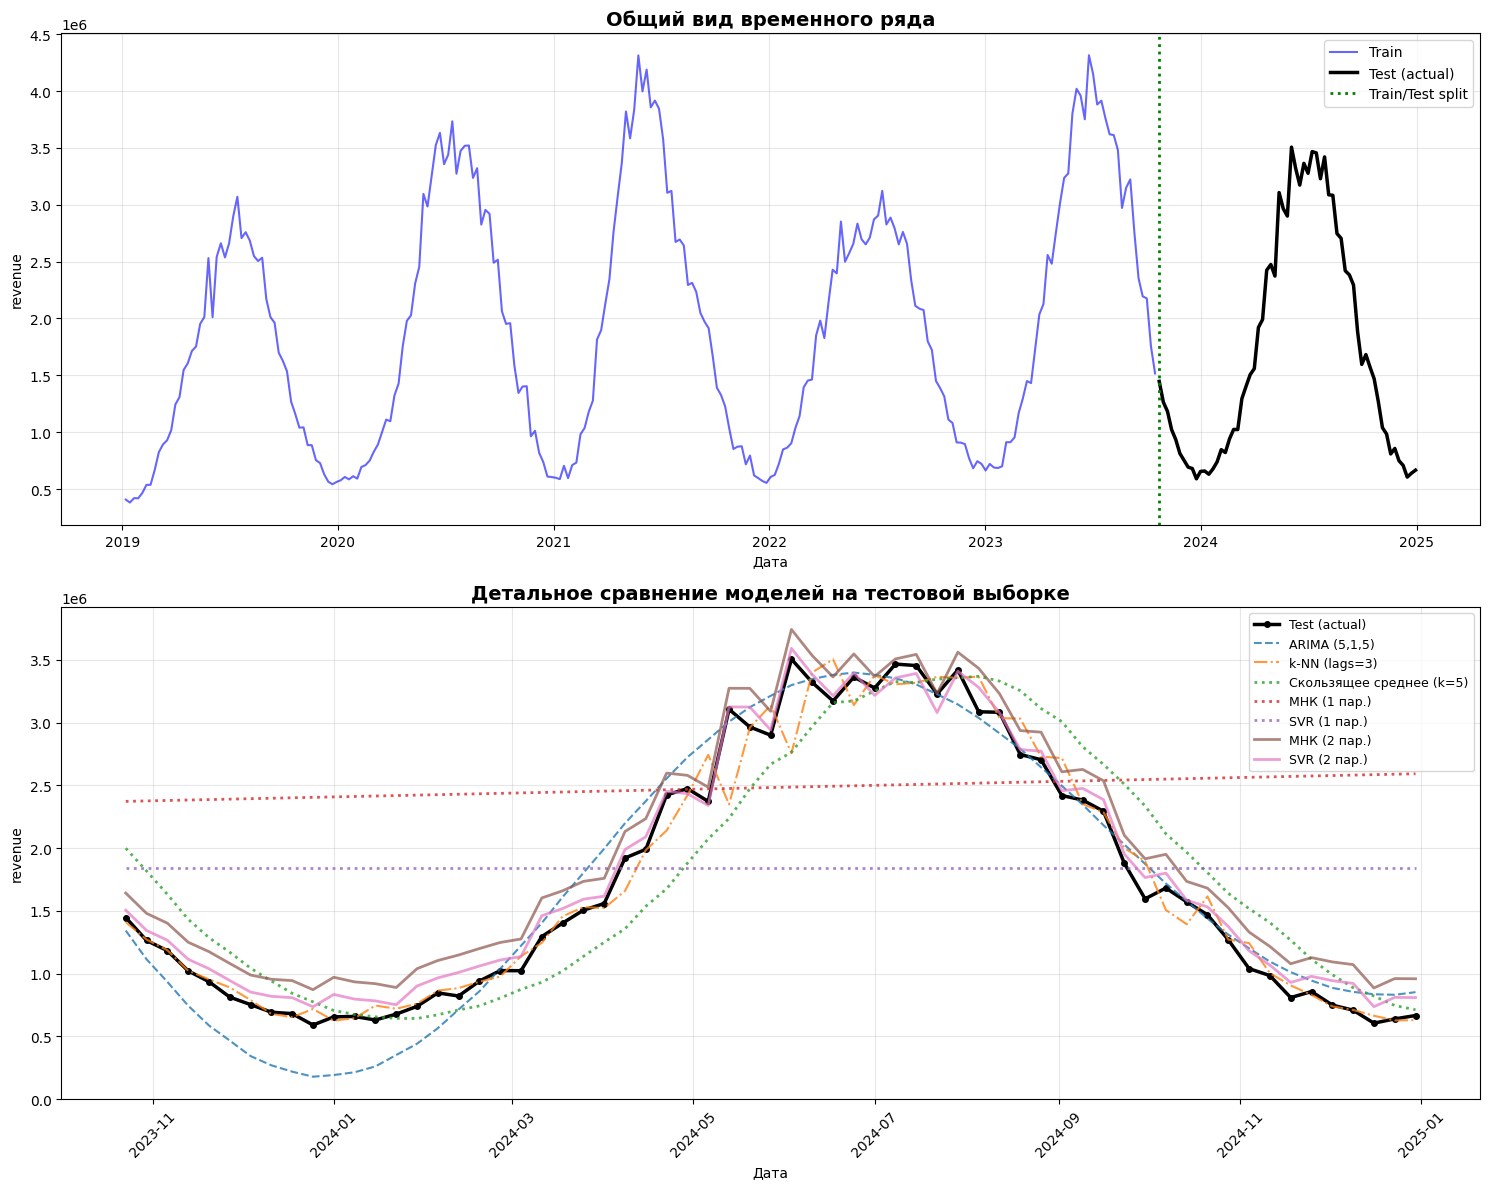

In [257]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

ax1.plot(dates[:split_idx], y_train, label='Train', color='blue',
         alpha=0.6, linewidth=1.5)
ax1.plot(dates[split_idx:], y_test, label='Test (actual)',
         color='black', linewidth=2.5)
ax1.axvline(x=dates[split_idx], color='green', linestyle=':',
            linewidth=2, label='Train/Test split')
ax1.set_title('Общий вид временного ряда', fontsize=14, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel(VALUE_COL)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2.plot(dates_test, y_test, label='Test (actual)', color='black',
         linewidth=2.5, marker='o', markersize=4)
ax2.plot(dates_test, pred_arima, label='ARIMA (5,1,5)',
         linestyle='--', alpha=0.8)
ax2.plot(dates_test, pred_knn, label='k-NN (lags=3)',
         linestyle='-.', alpha=0.8)
ax2.plot(dates_test, ma_forecast, label=f'Скользящее среднее (k={window})',
         linestyle=':', alpha=0.8, linewidth=2)
ax2.plot(dates_test, pred_mnk, label='МНК (1 пар.)',
         linestyle=':', alpha=0.8, linewidth=2)
ax2.plot(dates_test, pred_svr, label='SVR (1 пар.)',
         linestyle=':', alpha=0.8, linewidth=2)
ax2.plot(dates_test, pred_mnk2, label='МНК (2 пар.)',
         linestyle='-', alpha=0.7, linewidth=2)
ax2.plot(dates_test, pred_svr2, label='SVR (2 пар.)',
         linestyle='-', alpha=0.7, linewidth=2)

ax2.set_title('Детальное сравнение моделей на тестовой выборке',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel(VALUE_COL)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [258]:
print(f'МНК: y = {mnk2_model.intercept_:.2f} '
      f'+ {mnk2_model.coef_[0]:.4f}·x1')
diff = np.abs(pred_mnk2 - pred_svr2)
print(f'max diff : {diff.max():,.0f}')
print(f'mean diff: {diff.mean():,.0f}')
print(f'RMSE diff: {np.sqrt(np.mean(diff**2)):,.0f}')

МНК: y = 13608.74 + 1098.2397·x1
max diff : 152,298
mean diff: 145,173
RMSE diff: 145,295


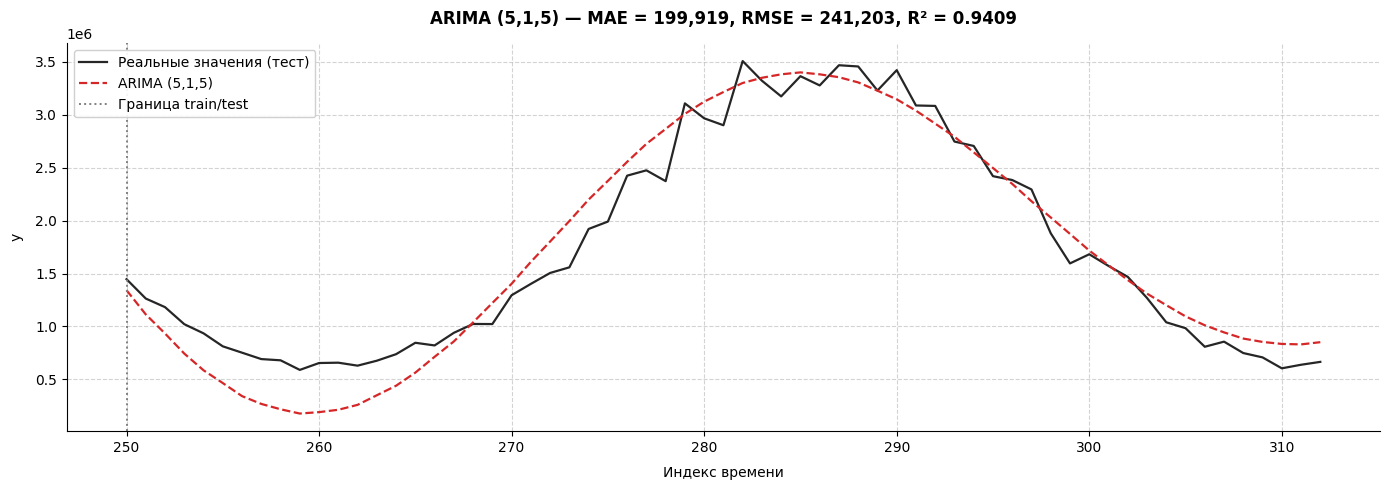

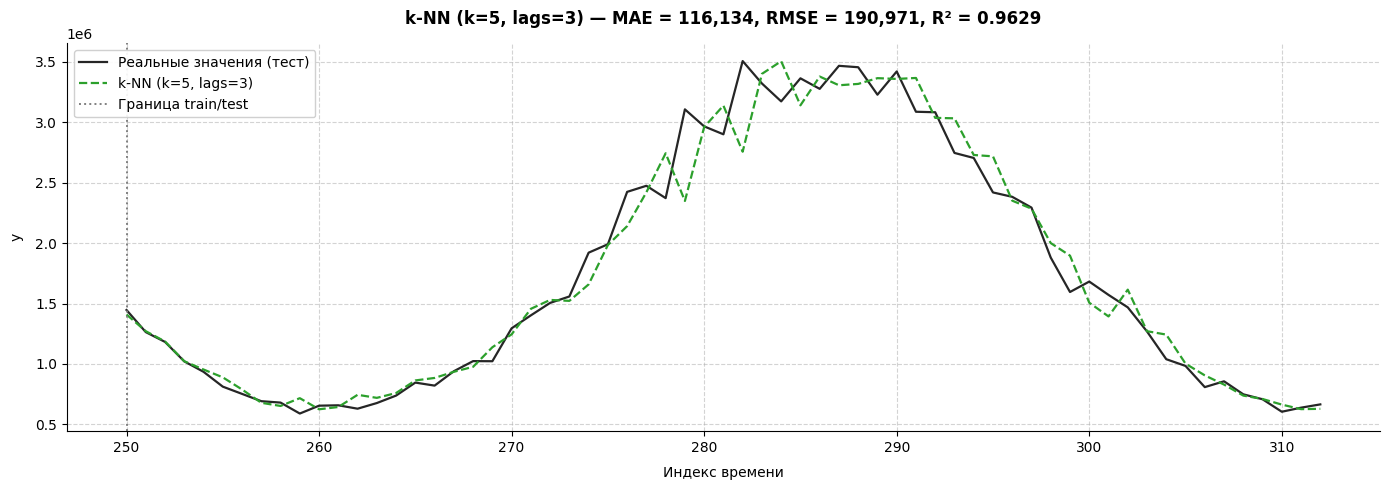

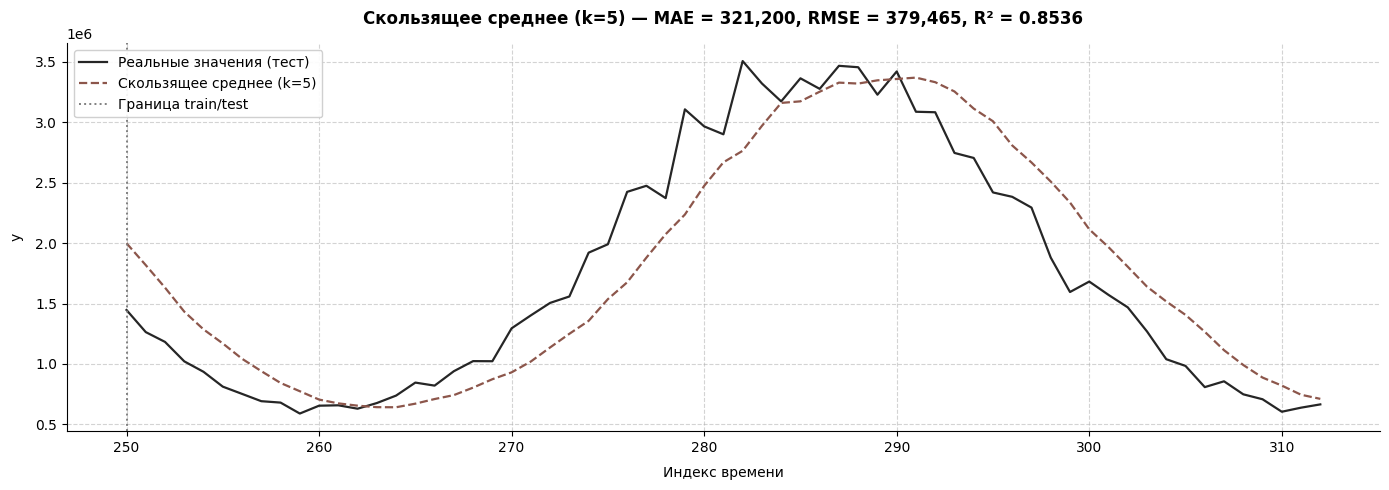

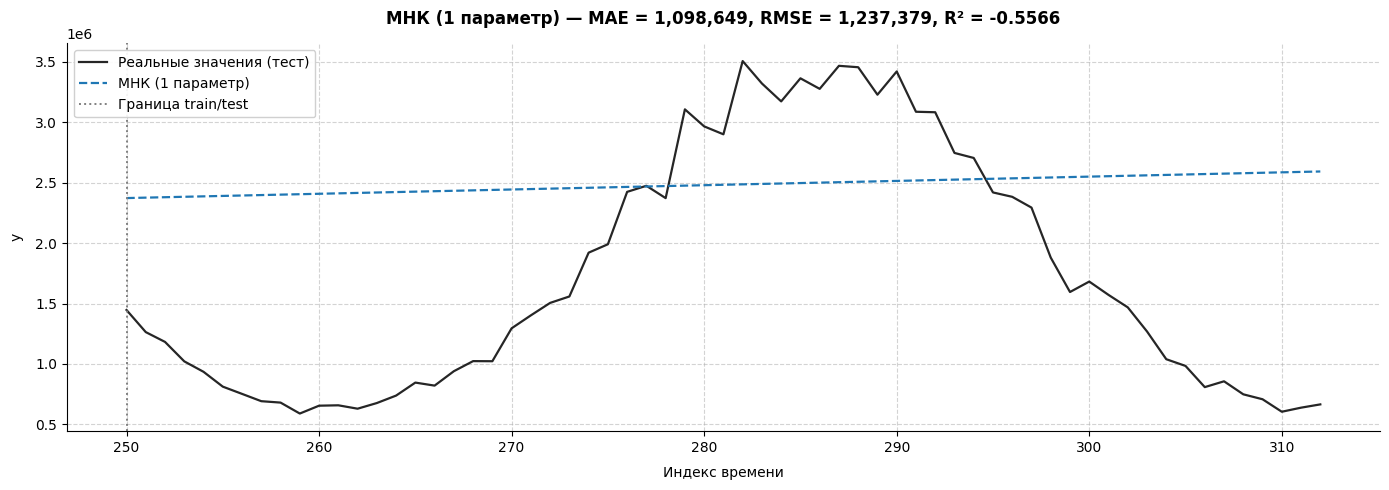

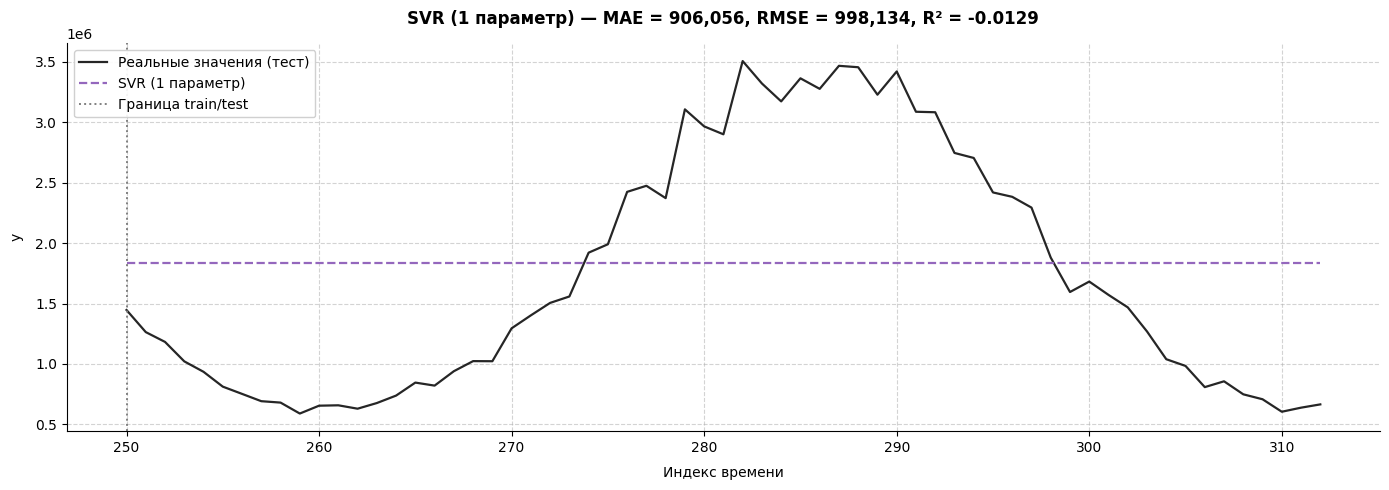

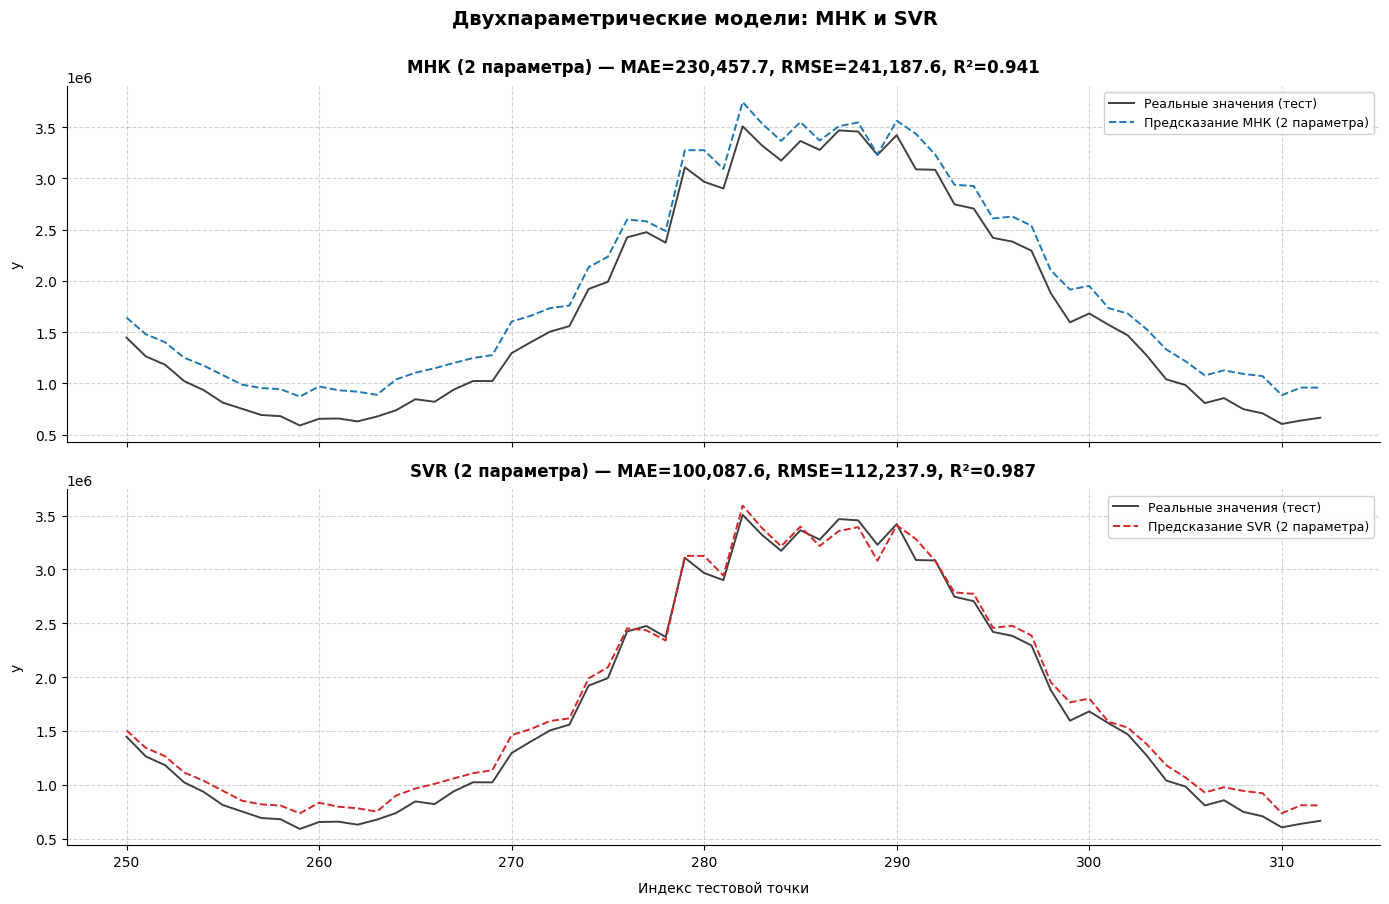

In [259]:
# согласуем длины: x_test_idx строим от длины y_test
x_test_idx = np.arange(split_idx, split_idx + len(y_test))

plots = [
    ('ARIMA (5,1,5)', pred_arima, '#d62728', m_arima),
    ('k-NN (k=5, lags=3)', pred_knn, '#2ca02c', m_knn),
    (f'Скользящее среднее (k={window})', ma_forecast, '#8c564b', m_ma),
    ('МНК (1 параметр)', pred_mnk, '#1f77b4', m_mnk),
    ('SVR (1 параметр)', pred_svr, '#9467bd', m_svr),
]

for name, pred, color, m in plots:
    if len(pred) != len(y_test):
        print(f'ПРОПУСК {name}: len(pred)={len(pred)}, len(y_test)={len(y_test)}')
        continue

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
            alpha=0.85, label='Реальные значения (тест)')
    ax.plot(x_test_idx, pred, color=color, linewidth=1.6,
            linestyle='--', label=name)
    ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
               label='Граница train/test')
    ax.set_xlabel('Индекс времени', labelpad=8)
    ax.set_ylabel('y', labelpad=8)
    ax.set_title(f'{name} — MAE = {m["MAE"]:,.0f}, '
                 f'RMSE = {m["RMSE"]:,.0f}, R² = {m["R2"]:.4f}',
                 pad=14, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

# ---------- Двухпараметрические модели ----------
x_test_idx_2 = np.arange(split_idx_2, split_idx_2 + len(y_test_2))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, pred, name, color, m in [
    (axes[0], pred_mnk2, 'МНК (2 параметра)', '#1f77b4', m_mnk2),
    (axes[1], pred_svr2, 'SVR (2 параметра)', '#d62728', m_svr2),
]:
    if len(pred) != len(y_test_2):
        ax.text(0.5, 0.5, f'Пропуск: len(pred)={len(pred)}',
                transform=ax.transAxes, ha='center')
        continue

    ax.plot(x_test_idx_2, y_test_2, color='black', linewidth=1.4,
            alpha=0.75, label='Реальные значения (тест)')
    ax.plot(x_test_idx_2, pred, color=color, linewidth=1.4,
            linestyle='--', label=f'Предсказание {name}')
    ax.set_ylabel('y', labelpad=8)
    ax.set_title(
        f'{name} — MAE={m["MAE"]:,.1f}, RMSE={m["RMSE"]:,.1f}, R²={m["R2"]:.3f}',
        pad=10, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.92)
    sns.despine(ax=ax, top=True, right=True)

axes[1].set_xlabel('Индекс тестовой точки', labelpad=8)
fig.suptitle('Двухпараметрические модели: МНК и SVR',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [260]:
print('Уравнение МНК (2 параметра):')
print(f'  y = {mnk2_model.intercept_:,.2f} '
      f'+ {mnk2_model.coef_[0]:.6f}·x1 '
      f'+ {mnk2_model.coef_[1]:.6f}·x2')
print(f'  c1 (вклад времени): {mnk2_model.coef_[0]:.6f}')
print(f'  c2 (вклад units):   {mnk2_model.coef_[1]:.6f}')
print()

diff = np.abs(pred_mnk2 - pred_svr2)
print('Разница предсказаний МНК vs SVR (2 параметра):')
print(f'  max diff : {diff.max():,.0f}')
print(f'  mean diff: {diff.mean():,.0f}')
print(f'  RMSE diff: {np.sqrt(np.mean(diff**2)):,.0f}')
print()
print(f'R² МНК (2 пар.): {m_mnk2["R2"]:.6f}')
print(f'R² SVR (2 пар.): {m_svr2["R2"]:.6f}')
print(f'ΔR²            : {m_svr2["R2"] - m_mnk2["R2"]:+.6f}')

Уравнение МНК (2 параметра):
  y = 13,608.74 + 1098.239665·x1 + 11.416292·x2
  c1 (вклад времени): 1098.239665
  c2 (вклад units):   11.416292

Разница предсказаний МНК vs SVR (2 параметра):
  max diff : 152,298
  mean diff: 145,173
  RMSE diff: 145,295

R² МНК (2 пар.): 0.940860
R² SVR (2 пар.): 0.987193
ΔR²            : +0.046333


In [261]:
df_lasso = pd.DataFrame({'y': y_full})
for lag in range(1, 6):
    df_lasso[f'lag_{lag}'] = df_lasso['y'].shift(lag)
df_lasso = df_lasso.dropna().reset_index(drop=True)

feature_cols = [c for c in df_lasso.columns if c != 'y']
print(f'Признаки: {feature_cols}')
print(f'Размер: {len(df_lasso)}')

split_idx_lasso = int(len(df_lasso) * 0.8)
train_l = df_lasso.iloc[:split_idx_lasso]
test_l = df_lasso.iloc[split_idx_lasso:]

X_train_l = train_l[feature_cols].values
y_train_l = train_l['y'].values
X_test_l = test_l[feature_cols].values
y_test_l = test_l['y'].values

scaler_l = StandardScaler()
X_train_l_s = scaler_l.fit_transform(X_train_l)
X_test_l_s = scaler_l.transform(X_test_l)

lasso_model = Lasso(alpha=1000.0, max_iter=50000, random_state=42)
lasso_model.fit(X_train_l_s, y_train_l)
pred_lasso = lasso_model.predict(X_test_l_s)

mae_lasso = mean_absolute_error(y_test_l, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test_l, pred_lasso))
r2_lasso = r2_score(y_test_l, pred_lasso)

print(f'\nLasso (α={lasso_model.alpha}):')
print(f'  MAE  = {mae_lasso:,.0f}')
print(f'  RMSE = {rmse_lasso:,.0f}')
print(f'  R²   = {r2_lasso:.4f}')
print(f'  Ненулевых коэффициентов: {int(np.sum(lasso_model.coef_ != 0))} из {len(feature_cols)}')

coef_df = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': lasso_model.coef_,
})
print('\nКоэффициенты:')
print(coef_df.to_string(index=False))

Признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']
Размер: 308

Lasso (α=1000.0):
  MAE  = 115,242
  RMSE = 158,081
  R²   = 0.9750
  Ненулевых коэффициентов: 5 из 5

Коэффициенты:
Признак    Коэффициент
  lag_1  788137.541139
  lag_2  404583.024215
  lag_3  263860.237443
  lag_4   -1111.650975
  lag_5 -460710.462651


In [262]:
n_components = min(3, len(feature_cols))

pls_model = PLSRegression(n_components=n_components, scale=False)
pls_model.fit(X_train_l_s, y_train_l)
pred_pls = pls_model.predict(X_test_l_s).ravel()

mae_pls = mean_absolute_error(y_test_l, pred_pls)
rmse_pls = np.sqrt(mean_squared_error(y_test_l, pred_pls))
r2_pls = r2_score(y_test_l, pred_pls)

print(f'PLS (n_components={n_components}):')
print(f'  MAE  = {mae_pls:,.0f}')
print(f'  RMSE = {rmse_pls:,.0f}')
print(f'  R²   = {r2_pls:.4f}')

PLS (n_components=3):
  MAE  = 114,249
  RMSE = 155,302
  R²   = 0.9758


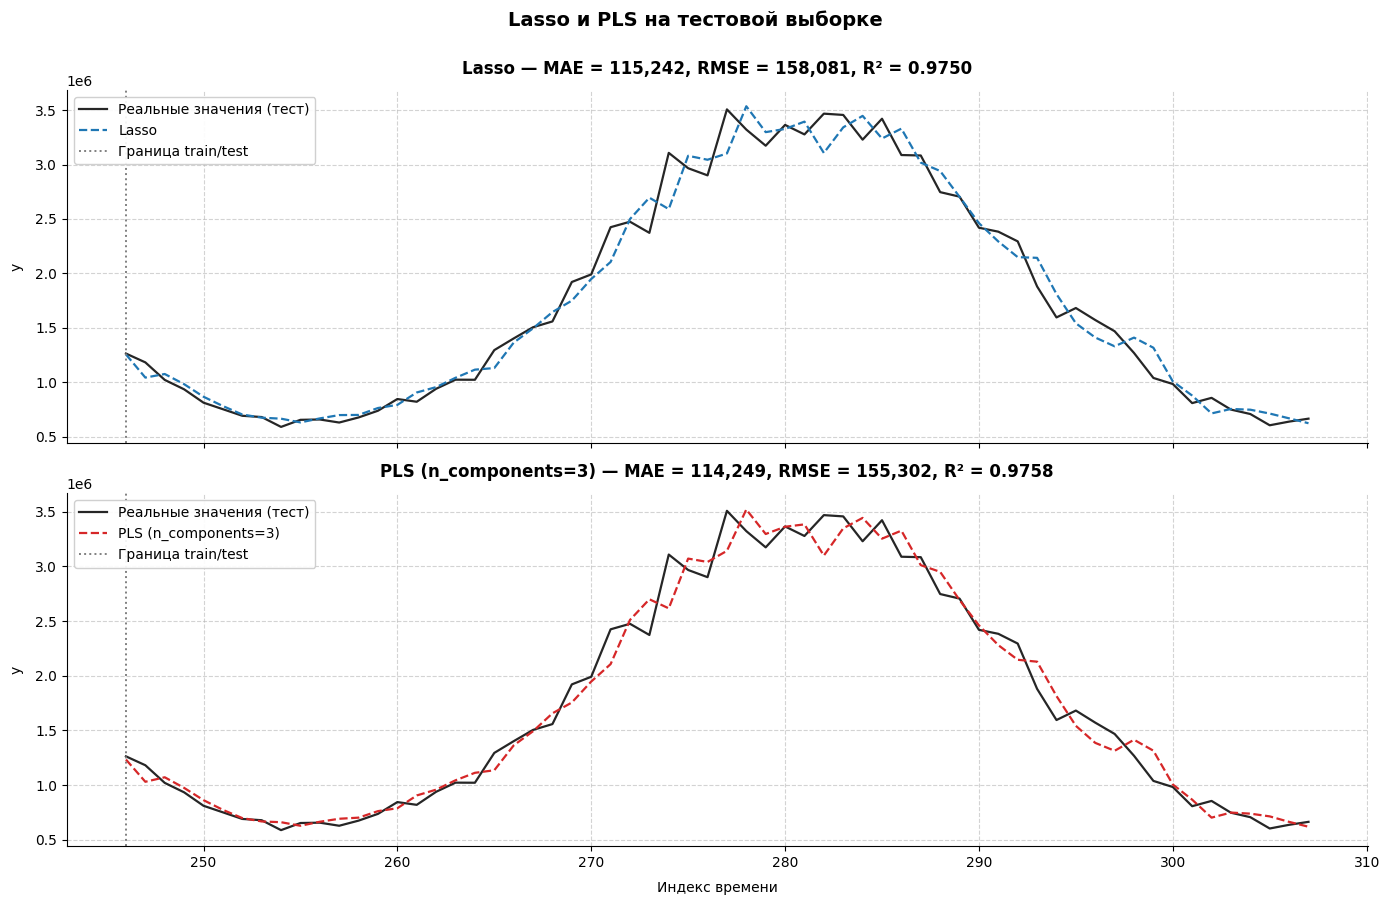


ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (по R²)
                             MAE          RMSE      R2
SVR 2п              1.000876e+05  1.122379e+05  0.9872
PLS                 1.142487e+05  1.553024e+05  0.9758
Lasso               1.152425e+05  1.580807e+05  0.9750
k-NN (k=5, lags=3)  1.161343e+05  1.909707e+05  0.9629
ARIMA (5,1,5)       1.999190e+05  2.412026e+05  0.9409
МНК 2п              2.304577e+05  2.411876e+05  0.9409
Скользящее среднее  3.211998e+05  3.794650e+05  0.8536
SVR 1п              9.060564e+05  9.981341e+05 -0.0129
МНК 1п              1.098649e+06  1.237379e+06 -0.5566


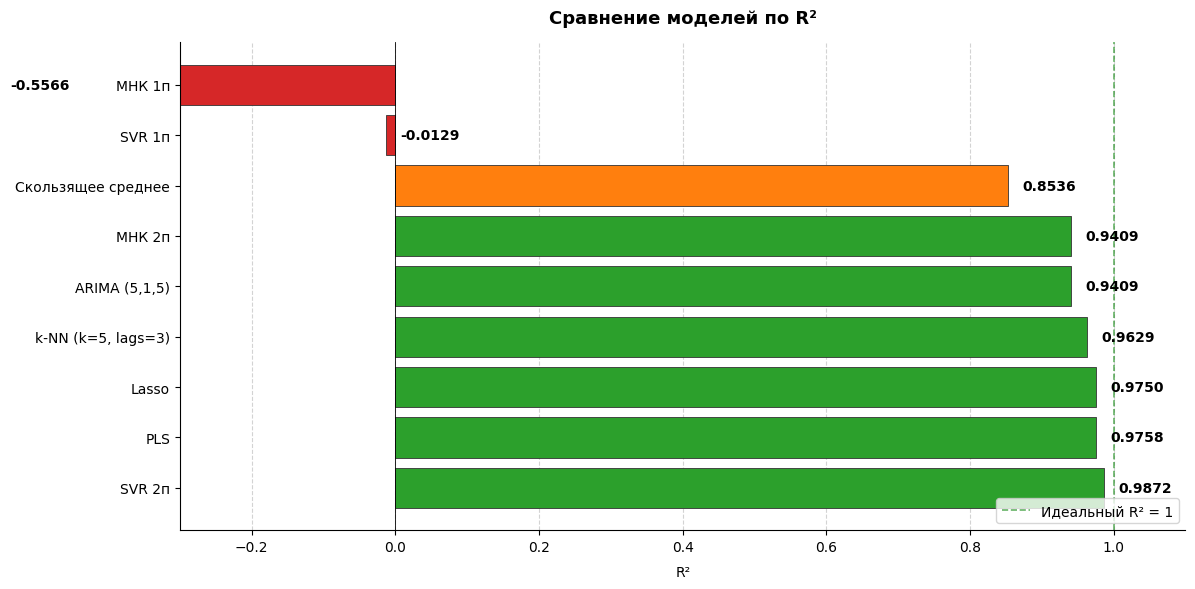

In [263]:
x_test_idx_l = np.arange(split_idx_lasso, split_idx_lasso + len(y_test_l))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, pred, name, color, m in [
    (axes[0], pred_lasso, 'Lasso', '#1f77b4',
     {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso}),
    (axes[1], pred_pls, f'PLS (n_components={n_components})', '#d62728',
     {'MAE': mae_pls, 'RMSE': rmse_pls, 'R2': r2_pls}),
]:
    ax.plot(x_test_idx_l, y_test_l, color='black', linewidth=1.6,
            alpha=0.85, label='Реальные значения (тест)')
    ax.plot(x_test_idx_l, pred, color=color, linewidth=1.6,
            linestyle='--', label=f'{name}')
    ax.axvline(split_idx_lasso, color='gray', linestyle=':',
               linewidth=1.4, label='Граница train/test')
    ax.set_ylabel('y', labelpad=8)
    ax.set_title(
        f'{name} — MAE = {m["MAE"]:,.0f}, '
        f'RMSE = {m["RMSE"]:,.0f}, R² = {m["R2"]:.4f}',
        pad=12, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
    sns.despine(ax=ax, top=True, right=True)

axes[1].set_xlabel('Индекс времени', labelpad=8)
fig.suptitle('Lasso и PLS на тестовой выборке',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# --- Сводная таблица R² по всем моделям ---
summary_all = pd.DataFrame({
    'ARIMA (5,1,5)':         m_arima,
    'k-NN (k=5, lags=3)':    m_knn,
    f'Скользящее среднее':   m_ma,
    'МНК 1п':                m_mnk,
    'SVR 1п':                m_svr,
    'МНК 2п':                m_mnk2,
    'SVR 2п':                m_svr2,
    'Lasso':                 {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso},
    'PLS':                   {'MAE': mae_pls, 'RMSE': rmse_pls, 'R2': r2_pls},
}).T.round(4)

summary_all = summary_all.sort_values('R2', ascending=False)
print('\n' + '=' * 70)
print('ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (по R²)')
print('=' * 70)
print(summary_all.to_string())

# --- График R² ---
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ca02c' if r2 > 0.9 else
          '#ff7f0e' if r2 > 0.5 else
          '#d62728' for r2 in summary_all['R2']]

bars = ax.barh(summary_all.index, summary_all['R2'],
               color=colors, edgecolor='#333333', linewidth=0.6)

for bar, r2 in zip(bars, summary_all['R2']):
    ax.text(r2 + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{r2:.4f}', va='center', fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(1, color='green', linewidth=1.2, linestyle='--',
           alpha=0.6, label='Идеальный R² = 1')
ax.set_xlabel('R²', labelpad=8)
ax.set_title('Сравнение моделей по R²', pad=14,
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.set_xlim(-0.3, 1.1)
ax.legend(loc='lower right', fontsize=10)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()

In [264]:
def build_lag_features(y, n_lags=5):
    df = pd.DataFrame({'y': y})
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    return df.dropna().reset_index(drop=True)


def run_lasso_experiment(y, train_frac, test_frac, alpha=1000.0, n_lags=5):
    df = build_lag_features(y, n_lags=n_lags)
    n = len(df)
    n_train = int(n * train_frac)
    n_test = int(n * test_frac)

    train = df.iloc[:n_train]
    test = df.iloc[n - n_test:]

    feature_cols = [c for c in df.columns if c != 'y']
    X_train = train[feature_cols].values
    y_train = train['y'].values
    X_test = test[feature_cols].values
    y_test = test['y'].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = Lasso(alpha=alpha, max_iter=50000, random_state=42)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    return {
        'n_train': len(train), 'n_test': len(test),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'pred': pred, 'y_test': y_test,
        'model': model, 'scaler': scaler,
        'feature_cols': feature_cols,
    }


n_total = len(y_full)
print(f'Всего точек в ряду: {n_total}')

exp_small = run_lasso_experiment(y_full, train_frac=0.4, test_frac=0.2)
exp_base  = run_lasso_experiment(y_full, train_frac=0.8, test_frac=0.2)
exp_large = run_lasso_experiment(y_full, train_frac=0.9, test_frac=0.1)

experiments = {
    'Train = 40 % (×0.5)': exp_small,
    'Train = 80 % (базовый)': exp_base,
    'Train = 90 % (×1.125)': exp_large,
}

rows = []
for name, exp in experiments.items():
    rows.append({
        'Сценарий': name,
        'N train': exp['n_train'],
        'N test': exp['n_test'],
        'MAE': exp['MAE'],
        'RMSE': exp['RMSE'],
        'R²': exp['R2'],
    })

summary_sizes = pd.DataFrame(rows).set_index('Сценарий').round(4)
print('\n' + '=' * 80)
print('ВЛИЯНИЕ РАЗМЕРА ОБУЧАЮЩЕЙ ВЫБОРКИ (Lasso, 5 лагов)')
print('=' * 80)
print(summary_sizes.to_string())

Всего точек в ряду: 313

ВЛИЯНИЕ РАЗМЕРА ОБУЧАЮЩЕЙ ВЫБОРКИ (Lasso, 5 лагов)
                        N train  N test          MAE         RMSE      R²
Сценарий                                                                 
Train = 40 % (×0.5)         123      61  114392.7216  156005.2201  0.9759
Train = 80 % (базовый)      246      61  116999.2385  159367.8235  0.9749
Train = 90 % (×1.125)       277      30  131067.4382  158003.0324  0.9772


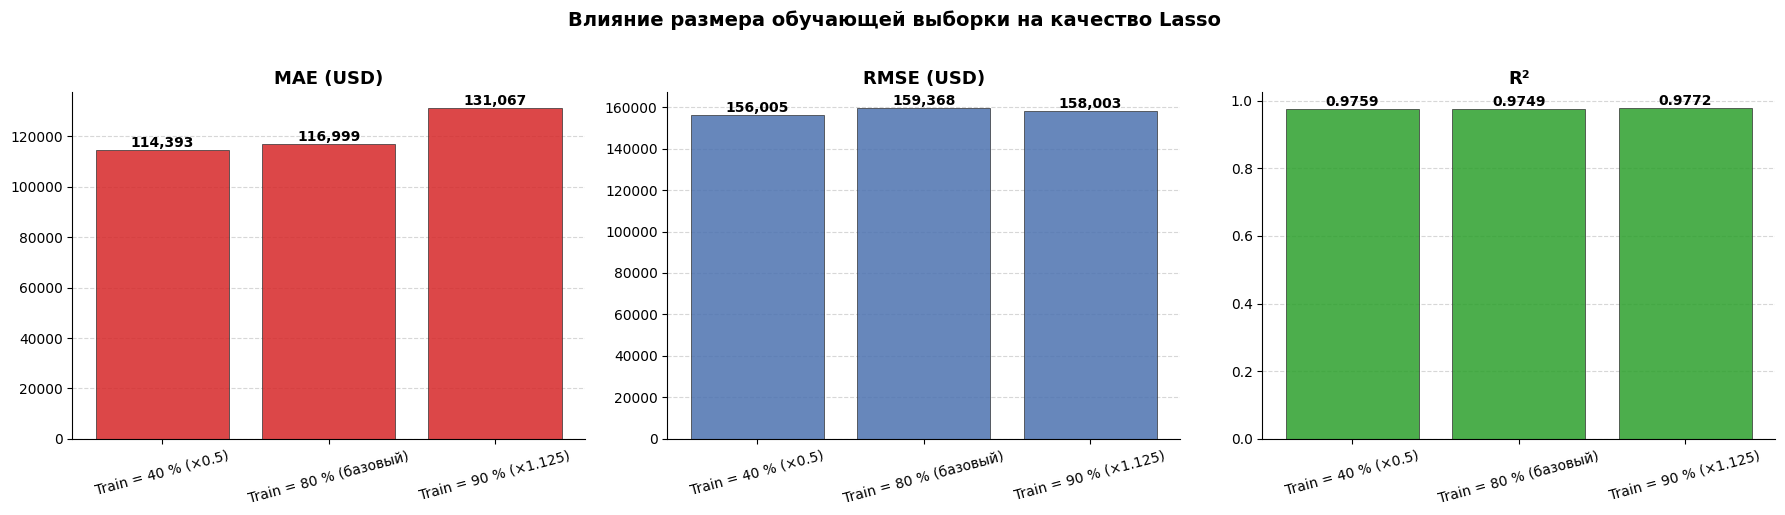

In [265]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = list(experiments.keys())
maes = [experiments[k]['MAE'] for k in names]
rmses = [experiments[k]['RMSE'] for k in names]
r2s = [experiments[k]['R2'] for k in names]
colors = ['#d62728', '#4c72b0', '#2ca02c']

for ax, values, metric, color in zip(
    axes,
    [maes, rmses, r2s],
    ['MAE (USD)', 'RMSE (USD)', 'R²'],
    colors,
):
    bars = ax.bar(names, values, color=color, edgecolor='#333333',
                  linewidth=0.6, alpha=0.85)
    for bar, v in zip(bars, values):
        label = f'{v:,.0f}' if metric != 'R²' else f'{v:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, top=True, right=True)

fig.suptitle('Влияние размера обучающей выборки на качество Lasso',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

СРАВНЕНИЕ DIRECT vs RECURSIVE
Режим                   MAE           RMSE         R²
----------------------------------------------------------------------
Direct              116,999        159,368     0.9749
Recursive           467,113        592,508     0.6527


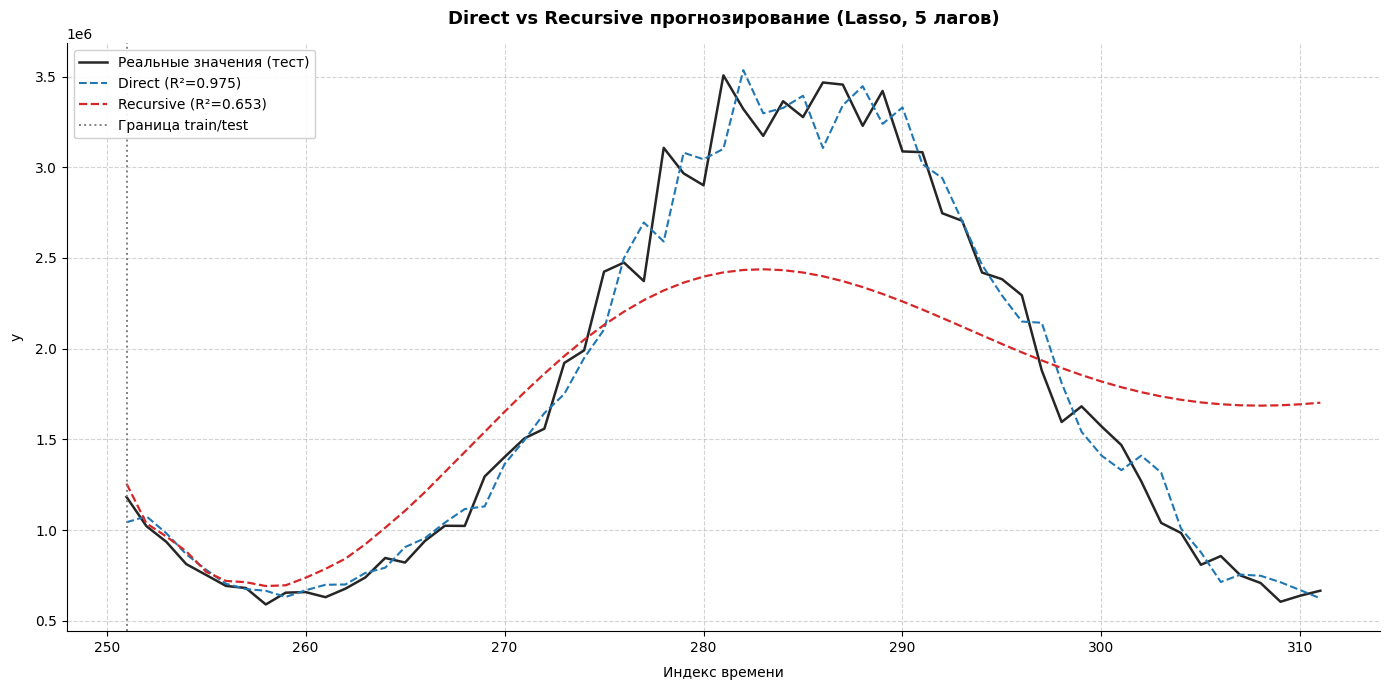

In [266]:
def direct_forecast(exp):
    return exp['pred'].copy()


def recursive_forecast(exp, n_lags=5):
    model = exp['model']
    scaler = exp['scaler']
    y_train_full = y_full[:exp['n_train'] + n_lags]

    history = list(y_train_full[-n_lags:])[::-1]
    preds = []

    for _ in range(exp['n_test']):
        x = np.array(history[:n_lags]).reshape(1, -1)
        x_s = scaler.transform(x)
        y_hat = model.predict(x_s)[0]
        preds.append(y_hat)
        history = [y_hat] + history[:-1]

    return np.array(preds)


pred_direct = direct_forecast(exp_base)
pred_recursive = recursive_forecast(exp_base)

y_test_compare = exp_base['y_test']

mae_direct = mean_absolute_error(y_test_compare, pred_direct)
rmse_direct = np.sqrt(mean_squared_error(y_test_compare, pred_direct))
r2_direct = r2_score(y_test_compare, pred_direct)

mae_rec = mean_absolute_error(y_test_compare, pred_recursive)
rmse_rec = np.sqrt(mean_squared_error(y_test_compare, pred_recursive))
r2_rec = r2_score(y_test_compare, pred_recursive)

print('=' * 70)
print('СРАВНЕНИЕ DIRECT vs RECURSIVE')
print('=' * 70)
print(f'{"Режим":12s} {"MAE":>14s} {"RMSE":>14s} {"R²":>10s}')
print('-' * 70)
print(f'{"Direct":12s} {mae_direct:>14,.0f} {rmse_direct:>14,.0f} {r2_direct:>10.4f}')
print(f'{"Recursive":12s} {mae_rec:>14,.0f} {rmse_rec:>14,.0f} {r2_rec:>10.4f}')

# --- график ---
x_test_idx_rec = np.arange(exp_base['n_train'] + 5,
                           exp_base['n_train'] + 5 + len(y_test_compare))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(x_test_idx_rec, y_test_compare, color='black', linewidth=1.8,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx_rec, pred_direct, color='#1f77b4', linewidth=1.5,
        linestyle='--', label=f'Direct (R²={r2_direct:.3f})')
ax.plot(x_test_idx_rec, pred_recursive, color='#d62728', linewidth=1.6,
        linestyle='--', label=f'Recursive (R²={r2_rec:.3f})')
ax.axvline(exp_base['n_train'] + 5, color='gray', linestyle=':',
           linewidth=1.4, label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title('Direct vs Recursive прогнозирование (Lasso, 5 лагов)',
             pad=14, fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()

In [267]:
summary_final = pd.DataFrame({
    'Train=40% Direct':    {'MAE': exp_small['MAE'],
                            'RMSE': exp_small['RMSE'],
                            'R²': exp_small['R2']},
    'Train=80% Direct':    {'MAE': mae_direct, 'RMSE': rmse_direct, 'R²': r2_direct},
    'Train=80% Recursive': {'MAE': mae_rec, 'RMSE': rmse_rec, 'R²': r2_rec},
    'Train=90% Direct':    {'MAE': exp_large['MAE'],
                            'RMSE': exp_large['RMSE'],
                            'R²': exp_large['R2']},
}).T

print('\n' + '=' * 75)
print('ИТОГОВОЕ СРАВНЕНИЕ (Lasso)')
print('=' * 75)
print(summary_final.round(4).to_string())


ИТОГОВОЕ СРАВНЕНИЕ (Lasso)
                             MAE         RMSE      R²
Train=40% Direct     114392.7216  156005.2201  0.9759
Train=80% Direct     116999.2385  159367.8235  0.9749
Train=80% Recursive  467113.1669  592508.3493  0.6527
Train=90% Direct     131067.4382  158003.0324  0.9772
